# 03 — Analyze KSC weather and effective acoustic speed

Use KSC tower observations and the canonical SLC-40–BCHH geometry from Notebook 02 to estimate still-air sound speed, along-path wind, effective acoustic speed, and short-range travel time.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.dates import DateFormatter
from pyproj import Geod

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

MODULE_DIR = PROJECT_ROOT / "modules"
if not MODULE_DIR.exists():
    # This makes the downloaded notebook work alongside the supplied module.
    MODULE_DIR = CURRENT_DIR.parent / "modules"
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from weather_analysis_fixed import (
    KNOT_TO_MPS,
    along_ray_wind_component,
    calculate_acoustic_summary,
    load_ksc_weather_excel,
    make_height_profile,
    make_time_profile,
    path_average_wind_profile,
    subset_time_window,
    summarize_wind,
)
from physics import compute_speed_of_sound

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "weather"
FIGURE_DIR = OUTPUT_DIR / "figures"
DERIVED_DIR = OUTPUT_DIR / "derived"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})


## 1. Configuration

In [2]:
WEATHER_FILE = PROJECT_ROOT / "metadata" / "nasa_weather_tower_data.xls"
ANALYSIS_CONFIG_FILE = PROJECT_ROOT / "outputs" / "derived" / "analysis_configuration.json"

if not ANALYSIS_CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Run 02_prepare_analysis_inputs.ipynb first: {ANALYSIS_CONFIG_FILE}"
    )

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
slc40 = analysis_config["slc40"]
array_reference = analysis_config["array_reference"]

ANALYSIS_START = pd.Timestamp("2016-09-01T13:05:00Z")
ANALYSIS_END = pd.Timestamp("2016-09-01T13:35:00Z")
MAXIMUM_PATH_HEIGHT_M = 65.0
HEIGHT_BIN_M = 10.0

geod = Geod(ellps="WGS84")
ray_azimuth_deg, _, propagation_distance_m = geod.inv(
    slc40["longitude"], slc40["latitude"],
    array_reference["longitude"], array_reference["latitude"],
)
ray_azimuth_deg %= 360.0

print(f"Weather file: {WEATHER_FILE}")
print(f"Analysis interval: {ANALYSIS_START} to {ANALYSIS_END}")
print(f"SLC-40 → BCHH azimuth: {ray_azimuth_deg:.3f}°")
print(f"SLC-40 → BCHH distance: {propagation_distance_m:.1f} m")


Weather file: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/metadata/nasa_weather_tower_data.xls
Analysis interval: 2016-09-01 13:05:00+00:00 to 2016-09-01 13:35:00+00:00
SLC-40 → BCHH azimuth: 19.404°
SLC-40 → BCHH distance: 1417.9 m


## 2. Load and validate the spreadsheet

In [3]:
weather_all = load_ksc_weather_excel(WEATHER_FILE)
weather = subset_time_window(
    weather_all,
    ANALYSIS_START,
    ANALYSIS_END,
)

print(f"All rows: {len(weather_all)}")
print(f"Rows in analysis interval: {len(weather)}")
print(
    "Towers/measurement locations:",
    weather["Tower Measurement Location"].nunique(),
)
print(
    "Height range:",
    f"{weather['height_m'].min():.1f}–"
    f"{weather['height_m'].max():.1f} m",
)
print("Observation times:", weather["datetime_utc"].nunique())

display(
    weather[
        [
            "datetime_utc",
            "Tower Measurement Location",
            "height_ft",
            "height_m",
            "wind_direction_from_deg",
            "wind_speed_knots",
            "temperature_f",
            "relative_humidity_percent",
        ]
    ].head()
)

All rows: 180
Rows in analysis interval: 105
Towers/measurement locations: 3
Height range: 16.5–139.9 m
Observation times: 7


,datetime_utc,Tower Measurement Location,height_ft,height_m,wind_direction_from_deg,wind_speed_knots,temperature_f,relative_humidity_percent
0,2016-09-01 13:05:00+00:00,SLC 40,54,16.4592,NaN,NaN,NaN,NaN
1,2016-09-01 13:10:00+00:00,SLC 40,54,16.4592,NaN,NaN,NaN,NaN
2,2016-09-01 13:15:00+00:00,SLC 40,54,16.4592,NaN,NaN,NaN,NaN
3,2016-09-01 13:20:00+00:00,SLC 40,54,16.4592,NaN,NaN,NaN,NaN
4,2016-09-01 13:25:00+00:00,SLC 40,54,16.4592,NaN,NaN,NaN,NaN


## 3. Overall atmospheric summaries

In [4]:
wind_summary = summarize_wind(weather)

overall_summary = pd.DataFrame(
    [
        {
            "analysis_start_utc": ANALYSIS_START,
            "analysis_end_utc": ANALYSIS_END,
            "n_rows": len(weather),
            "n_locations": weather[
                "Tower Measurement Location"
            ].nunique(),
            "minimum_height_m": weather["height_m"].min(),
            "maximum_height_m": weather["height_m"].max(),
            "mean_temperature_f": weather["temperature_f"].mean(),
            "std_temperature_f": weather["temperature_f"].std(),
            "n_temperature": weather["temperature_f"].count(),
            "mean_relative_humidity_percent": weather[
                "relative_humidity_percent"
            ].mean(),
            "std_relative_humidity_percent": weather[
                "relative_humidity_percent"
            ].std(),
            "n_humidity": weather[
                "relative_humidity_percent"
            ].count(),
            "scalar_mean_wind_speed_knots": (
                wind_summary.scalar_mean_speed_knots
            ),
            "vector_mean_wind_speed_knots": (
                wind_summary.vector_mean_speed_knots
            ),
            "vector_mean_wind_direction_from_deg": (
                wind_summary.vector_mean_direction_from_deg
            ),
        }
    ]
)

display(overall_summary.T)
overall_summary.to_csv(
    DERIVED_DIR / "weather_overall_summary.csv",
    index=False,
)

,0
analysis_start_utc,2016-09-01 13:05:00+00:00
analysis_end_utc,2016-09-01 13:35:00+00:00
n_rows,105
n_locations,3
minimum_height_m,16.4592
maximum_height_m,139.9032
mean_temperature_f,79.444048
std_temperature_f,0.49023
n_temperature,84
mean_relative_humidity_percent,83.869048


## 4. Height and time profiles

In [5]:
height_profile = make_height_profile(
    weather,
    height_bin_m=HEIGHT_BIN_M,
)
time_profile = make_time_profile(weather)

height_profile["wind_along_slc40_bchh_mps"] = (
    along_ray_wind_component(
        height_profile["mean_u_east_mps"],
        height_profile["mean_v_north_mps"],
        ray_azimuth_deg,
    )
)

display(height_profile)
display(time_profile)

height_profile.to_csv(
    DERIVED_DIR / "weather_height_profile.csv",
    index=False,
)
time_profile.to_csv(
    DERIVED_DIR / "weather_time_profile.csv",
    index=False,
)

,height_bin_lower_m,height_bin_upper_m,height_bin_mid_m,n_wind,mean_height_m,mean_u_east_mps,mean_v_north_mps,scalar_mean_wind_speed_mps,scalar_std_wind_speed_mps,mean_temperature_c,std_temperature_c,n_temperature,mean_relative_humidity_percent,std_relative_humidity_percent,n_humidity,vector_mean_wind_speed_mps,vector_mean_wind_speed_knots,vector_mean_wind_direction_from_deg,wind_along_slc40_bchh_mps
0,10.0,20.0,15.0,0,16.4592,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN
1,40.0,50.0,45.0,21,40.5384,-2.499971,3.572922,4.385023,1.191236,26.719577,0.101647,21,86.428571,4.577897,21,4.360691,8.476513,145.019539,2.539409
2,70.0,80.0,75.0,35,75.2856,-3.462601,4.792332,6.041042,1.716873,26.462963,0.073142,21,83.285714,1.230563,21,5.912364,11.492726,144.150782,3.369740
3,110.0,120.0,115.0,21,116.7384,-3.228676,4.560392,5.634387,2.554028,26.171958,0.085895,21,81.666667,4.553387,21,5.587622,10.861478,144.702190,3.228692
4,130.0,140.0,135.0,21,139.5984,-3.216148,4.133067,5.340419,3.562227,26.076720,0.128472,21,84.095238,1.480026,21,5.236970,10.179864,142.111718,2.829802


,datetime_utc,n_wind,mean_u_east_mps,mean_v_north_mps,scalar_mean_wind_speed_mps,scalar_std_wind_speed_mps,mean_temperature_c,std_temperature_c,n_temperature,mean_relative_humidity_percent,std_relative_humidity_percent,n_humidity,vector_mean_wind_speed_mps,vector_mean_wind_speed_knots,vector_mean_wind_direction_from_deg
0,2016-09-01 13:05:00+00:00,14,-3.167292,4.187671,5.328170,2.384159,26.254630,0.246705,12,83.333333,3.749747,12,5.250555,10.206271,142.898422
1,2016-09-01 13:10:00+00:00,14,-3.314409,4.294588,5.511900,2.458330,26.291667,0.262857,12,83.666667,3.797926,12,5.424832,10.545038,142.340329
2,2016-09-01 13:15:00+00:00,14,-3.185355,4.260481,5.401662,2.485683,26.319444,0.287336,12,83.833333,4.018895,12,5.319604,10.340492,143.216322
3,2016-09-01 13:20:00+00:00,14,-3.201110,4.202360,5.364916,2.493568,26.351852,0.268359,12,84.000000,3.813850,12,5.282702,10.268759,142.701983
4,2016-09-01 13:25:00+00:00,14,-3.271803,4.372129,5.548646,2.456259,26.388889,0.271133,12,83.833333,3.996210,12,5.460788,10.614932,143.191325
5,2016-09-01 13:30:00+00:00,14,-3.164800,4.455090,5.548646,2.505494,26.435185,0.276089,12,84.083333,3.848455,12,5.464776,10.622685,144.610832
6,2016-09-01 13:35:00+00:00,14,-2.768925,4.608082,5.438408,2.410544,26.462963,0.296191,12,84.333333,3.797926,12,5.375999,10.450115,148.998994


## 5. Path-averaged wind and acoustic-speed calculation

In [6]:
path_wind = path_average_wind_profile(
    height_profile,
    maximum_height_m=MAXIMUM_PATH_HEIGHT_M,
    ray_azimuth_deg=ray_azimuth_deg,
)

acoustic_summary = calculate_acoustic_summary(
    weather,
    height_profile=height_profile,
    maximum_path_height_m=MAXIMUM_PATH_HEIGHT_M,
    ray_azimuth_deg=ray_azimuth_deg,
    propagation_distance_m=propagation_distance_m,
    compute_speed_of_sound=compute_speed_of_sound,
)

acoustic_summary_df = pd.DataFrame([acoustic_summary])
display(acoustic_summary_df.T)

acoustic_summary_df.to_csv(
    DERIVED_DIR / "weather_acoustic_summary.csv",
    index=False,
)

,0
n_temperature,84.000000
n_humidity,84.000000
mean_temperature_f,79.444048
mean_temperature_c,26.357804
mean_relative_humidity_percent,83.869048
still_air_sound_speed_mps,348.329579
ray_azimuth_deg,19.404176
propagation_distance_m,1417.930794
maximum_path_height_m,65.000000
path_vector_mean_wind_speed_mps,4.566164


## 6. Wind rose: all average-wind observations

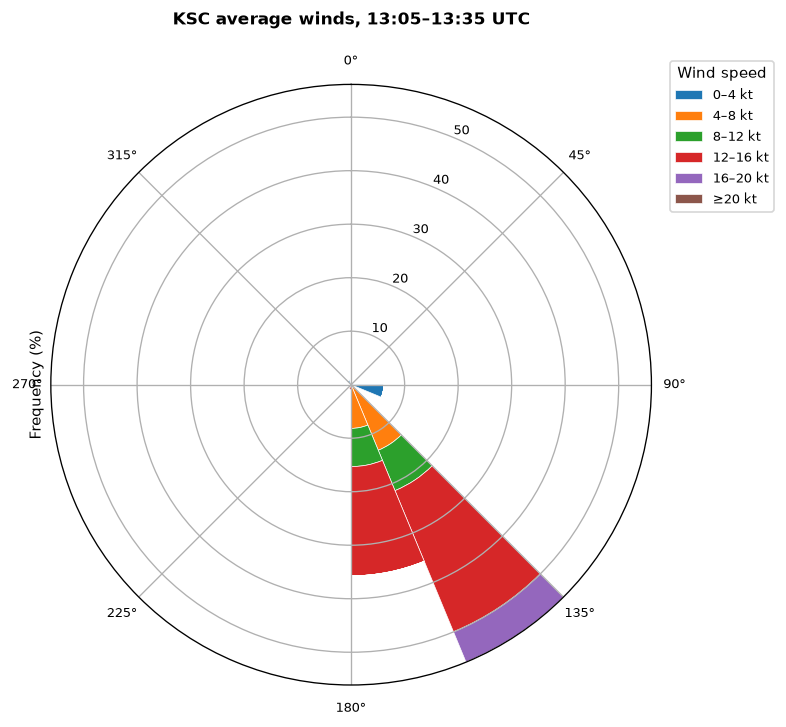

In [7]:
direction = weather["wind_direction_from_deg"].to_numpy(dtype=float)
speed = weather["wind_speed_knots"].to_numpy(dtype=float)

valid = np.isfinite(direction) & np.isfinite(speed)
direction = direction[valid]
speed = speed[valid]

direction_edges_deg = np.arange(0.0, 360.0 + 22.5, 22.5)
speed_edges_knots = np.array([0, 4, 8, 12, 16, 20, np.inf])

histogram = np.zeros(
    (len(direction_edges_deg) - 1, len(speed_edges_knots) - 1)
)

direction_wrapped = (
    direction + 0.5 * np.diff(direction_edges_deg)[0]
) % 360.0

for i in range(len(direction_edges_deg) - 1):
    direction_mask = (
        (direction_wrapped >= direction_edges_deg[i])
        & (direction_wrapped < direction_edges_deg[i + 1])
    )
    for j in range(len(speed_edges_knots) - 1):
        speed_mask = (
            (speed >= speed_edges_knots[j])
            & (speed < speed_edges_knots[j + 1])
        )
        histogram[i, j] = np.sum(direction_mask & speed_mask)

histogram = 100.0 * histogram / histogram.sum()

theta = np.deg2rad(
    direction_edges_deg[:-1]
    + 0.5 * np.diff(direction_edges_deg)
)
width = np.deg2rad(np.diff(direction_edges_deg))
bottom = np.zeros(len(theta))

fig = plt.figure(figsize=(7.0, 6.5))
ax = fig.add_subplot(111, projection="polar")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

labels = []
for j in range(histogram.shape[1]):
    values = histogram[:, j]
    ax.bar(
        theta,
        values,
        width=width,
        bottom=bottom,
        align="center",
        edgecolor="white",
        linewidth=0.4,
        label=(
            f"{speed_edges_knots[j]:g}–"
            f"{speed_edges_knots[j + 1]:g} kt"
            if np.isfinite(speed_edges_knots[j + 1])
            else f"≥{speed_edges_knots[j]:g} kt"
        ),
    )
    bottom += values

ax.set_title(
    "KSC average winds, 13:05–13:35 UTC",
    pad=18,
    fontweight="bold",
)
ax.set_ylabel("Frequency (%)")
ax.legend(
    title="Wind speed",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.05),
)

fig.savefig(
    FIGURE_DIR / "weather_wind_rose.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "weather_wind_rose.pdf",
    bbox_inches="tight",
)
plt.show()

## 7. Wind speed versus height

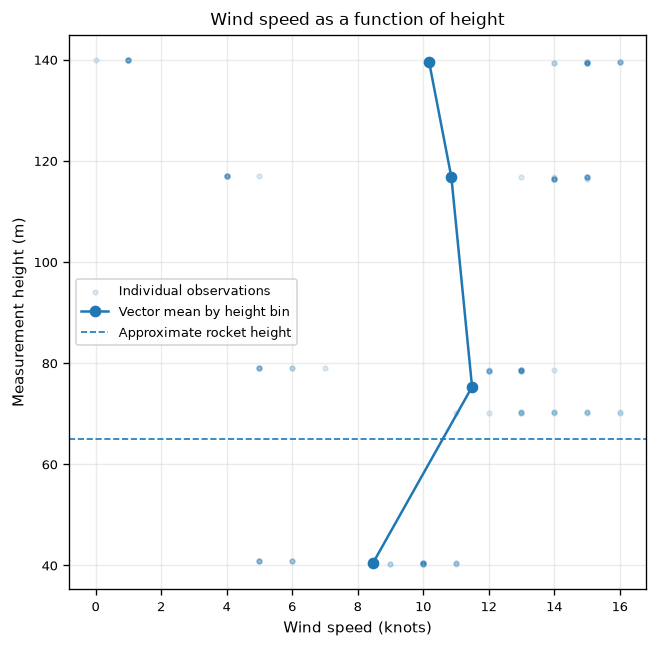

In [8]:
fig, ax = plt.subplots(figsize=(6.2, 6.0))

ax.scatter(
    weather["wind_speed_knots"],
    weather["height_m"],
    s=8,
    alpha=0.15,
    label="Individual observations",
)
ax.plot(
    height_profile["vector_mean_wind_speed_knots"],
    height_profile["mean_height_m"],
    marker="o",
    linewidth=1.5,
    label="Vector mean by height bin",
)
ax.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    linestyle="--",
    linewidth=1.0,
    label="Approximate rocket height",
)

ax.set_xlabel("Wind speed (knots)")
ax.set_ylabel("Measurement height (m)")
ax.set_title("Wind speed as a function of height")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    FIGURE_DIR / "weather_wind_speed_vs_height.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "weather_wind_speed_vs_height.pdf",
    bbox_inches="tight",
)
plt.show()

## 8. Wind direction versus height

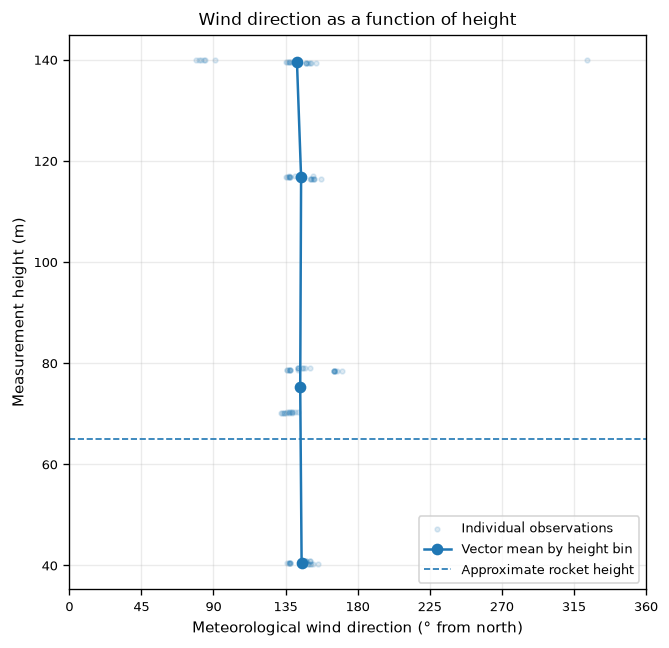

In [9]:
fig, ax = plt.subplots(figsize=(6.2, 6.0))

ax.scatter(
    weather["wind_direction_from_deg"],
    weather["height_m"],
    s=8,
    alpha=0.15,
    label="Individual observations",
)
ax.plot(
    height_profile["vector_mean_wind_direction_from_deg"],
    height_profile["mean_height_m"],
    marker="o",
    linewidth=1.5,
    label="Vector mean by height bin",
)
ax.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    linestyle="--",
    linewidth=1.0,
    label="Approximate rocket height",
)

ax.set_xlim(0, 360)
ax.set_xticks(np.arange(0, 361, 45))
ax.set_xlabel("Meteorological wind direction (° from north)")
ax.set_ylabel("Measurement height (m)")
ax.set_title("Wind direction as a function of height")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    FIGURE_DIR / "weather_wind_direction_vs_height.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "weather_wind_direction_vs_height.pdf",
    bbox_inches="tight",
)
plt.show()

## 9. Along-ray wind correction versus height

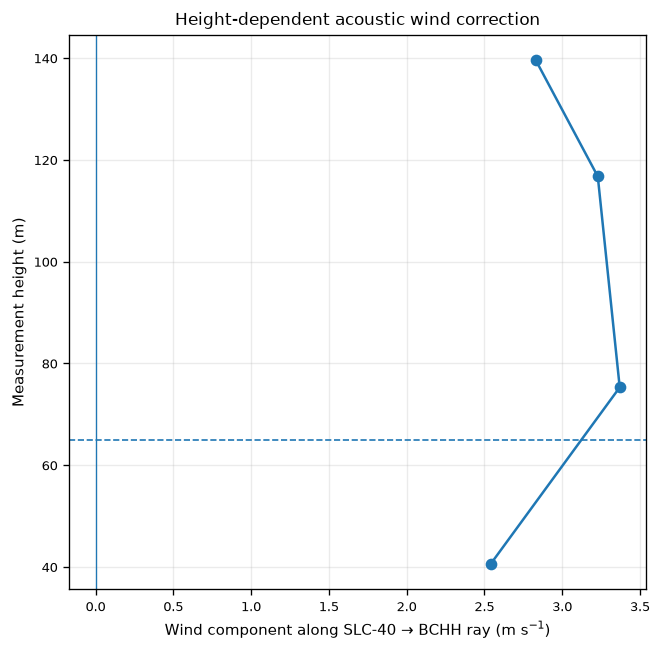

In [10]:
fig, ax = plt.subplots(figsize=(6.2, 6.0))

ax.axvline(0.0, linewidth=0.8)
ax.plot(
    height_profile["wind_along_slc40_bchh_mps"],
    height_profile["mean_height_m"],
    marker="o",
    linewidth=1.5,
)
ax.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    linestyle="--",
    linewidth=1.0,
)

ax.set_xlabel(
    "Wind component along SLC-40 → BCHH ray (m s$^{-1}$)"
)
ax.set_ylabel("Measurement height (m)")
ax.set_title("Height-dependent acoustic wind correction")
ax.grid(True, alpha=0.25)

fig.savefig(
    FIGURE_DIR / "weather_along_ray_wind_vs_height.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "weather_along_ray_wind_vs_height.pdf",
    bbox_inches="tight",
)
plt.show()

## 10. Temperature versus height

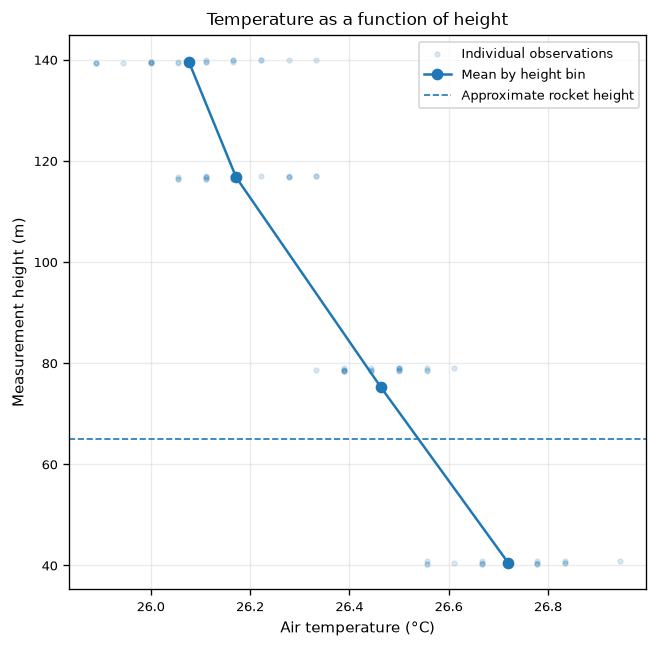

In [11]:
valid_profile = height_profile.dropna(
    subset=["mean_temperature_c"]
)

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(
    weather["temperature_c"],
    weather["height_m"],
    s=8,
    alpha=0.15,
    label="Individual observations",
)
ax.plot(
    valid_profile["mean_temperature_c"],
    valid_profile["mean_height_m"],
    marker="o",
    linewidth=1.5,
    label="Mean by height bin",
)
ax.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    linestyle="--",
    linewidth=1.0,
    label="Approximate rocket height",
)

ax.set_xlabel("Air temperature (°C)")
ax.set_ylabel("Measurement height (m)")
ax.set_title("Temperature as a function of height")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    FIGURE_DIR / "weather_temperature_vs_height.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "weather_temperature_vs_height.pdf",
    bbox_inches="tight",
)
plt.show()

## 11. Relative humidity versus height

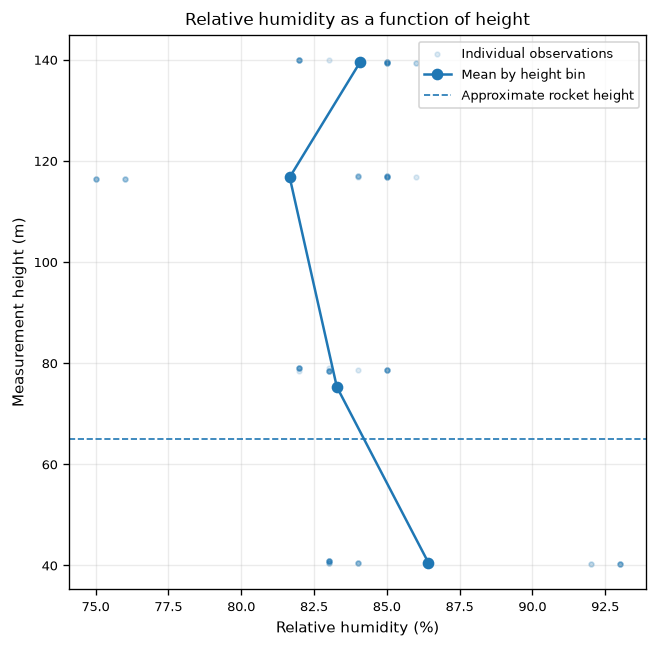

In [12]:
valid_profile = height_profile.dropna(
    subset=["mean_relative_humidity_percent"]
)

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(
    weather["relative_humidity_percent"],
    weather["height_m"],
    s=8,
    alpha=0.15,
    label="Individual observations",
)
ax.plot(
    valid_profile["mean_relative_humidity_percent"],
    valid_profile["mean_height_m"],
    marker="o",
    linewidth=1.5,
    label="Mean by height bin",
)
ax.axhline(
    MAXIMUM_PATH_HEIGHT_M,
    linestyle="--",
    linewidth=1.0,
    label="Approximate rocket height",
)

ax.set_xlabel("Relative humidity (%)")
ax.set_ylabel("Measurement height (m)")
ax.set_title("Relative humidity as a function of height")
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    FIGURE_DIR / "weather_humidity_vs_height.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "weather_humidity_vs_height.pdf",
    bbox_inches="tight",
)
plt.show()

## 12. Wind speed through time

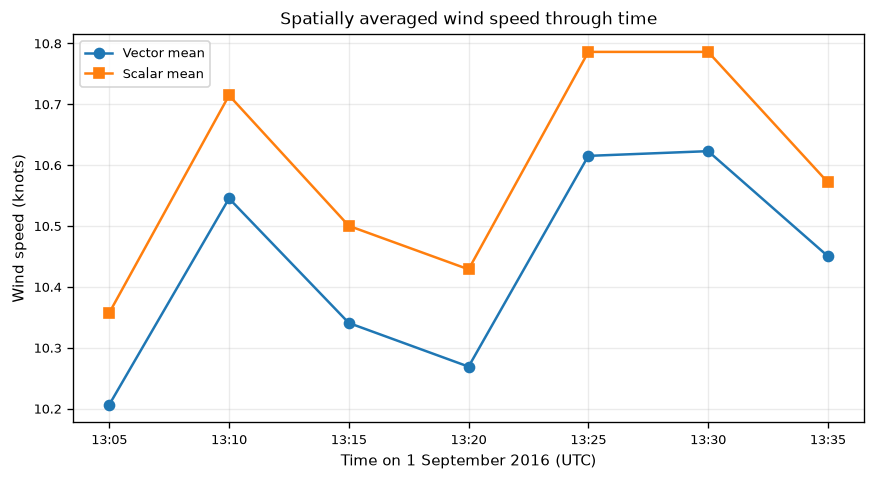

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

ax.plot(
    time_profile["datetime_utc"],
    time_profile["vector_mean_wind_speed_knots"],
    marker="o",
    label="Vector mean",
)
ax.plot(
    time_profile["datetime_utc"],
    time_profile["scalar_mean_wind_speed_mps"] / KNOT_TO_MPS,
    marker="s",
    label="Scalar mean",
)

ax.set_xlabel("Time on 1 September 2016 (UTC)")
ax.set_ylabel("Wind speed (knots)")
ax.set_title("Spatially averaged wind speed through time")
ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax.grid(True, alpha=0.25)
ax.legend()

fig.savefig(
    FIGURE_DIR / "weather_wind_speed_vs_time.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "weather_wind_speed_vs_time.pdf",
    bbox_inches="tight",
)
plt.show()

## 13. Wind direction through time

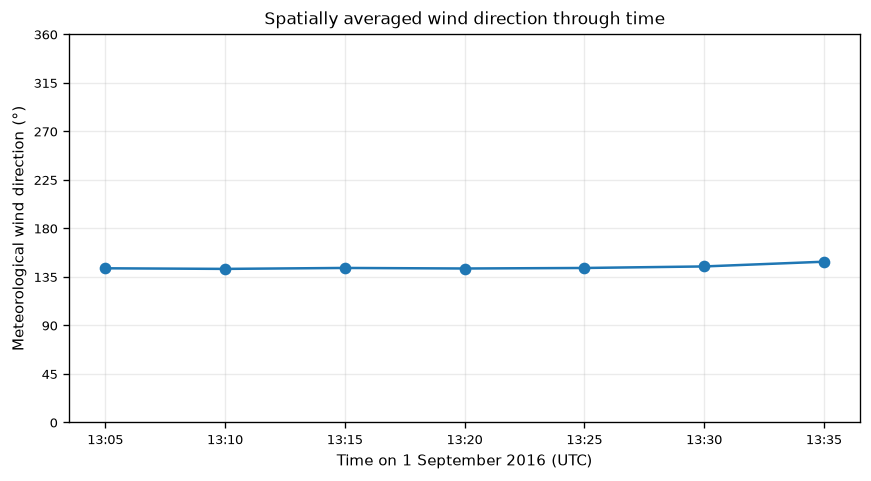

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

ax.plot(
    time_profile["datetime_utc"],
    time_profile["vector_mean_wind_direction_from_deg"],
    marker="o",
)

ax.set_ylim(0, 360)
ax.set_yticks(np.arange(0, 361, 45))
ax.set_xlabel("Time on 1 September 2016 (UTC)")
ax.set_ylabel("Meteorological wind direction (°)")
ax.set_title("Spatially averaged wind direction through time")
ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax.grid(True, alpha=0.25)

fig.savefig(
    FIGURE_DIR / "weather_wind_direction_vs_time.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "weather_wind_direction_vs_time.pdf",
    bbox_inches="tight",
)
plt.show()

## 14. Temperature through time

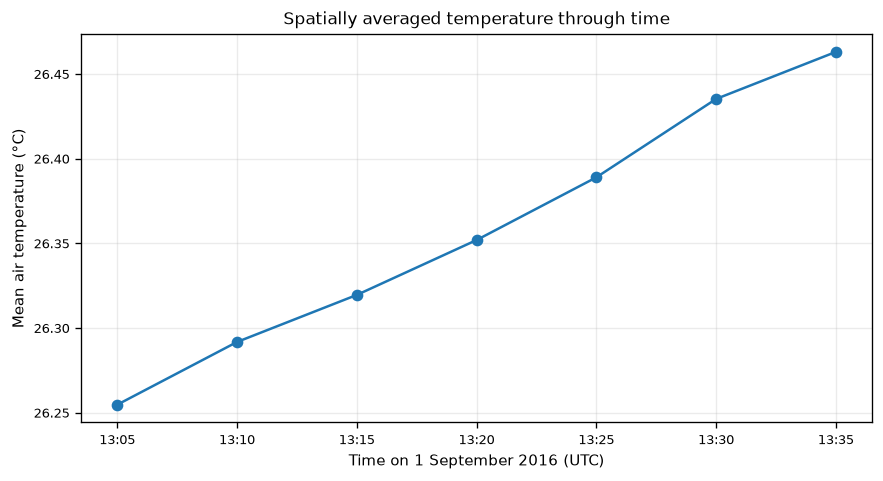

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

ax.plot(
    time_profile["datetime_utc"],
    time_profile["mean_temperature_c"],
    marker="o",
)

ax.set_xlabel("Time on 1 September 2016 (UTC)")
ax.set_ylabel("Mean air temperature (°C)")
ax.set_title("Spatially averaged temperature through time")
ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax.grid(True, alpha=0.25)

fig.savefig(
    FIGURE_DIR / "weather_temperature_vs_time.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "weather_temperature_vs_time.pdf",
    bbox_inches="tight",
)
plt.show()

## 15. Relative humidity through time

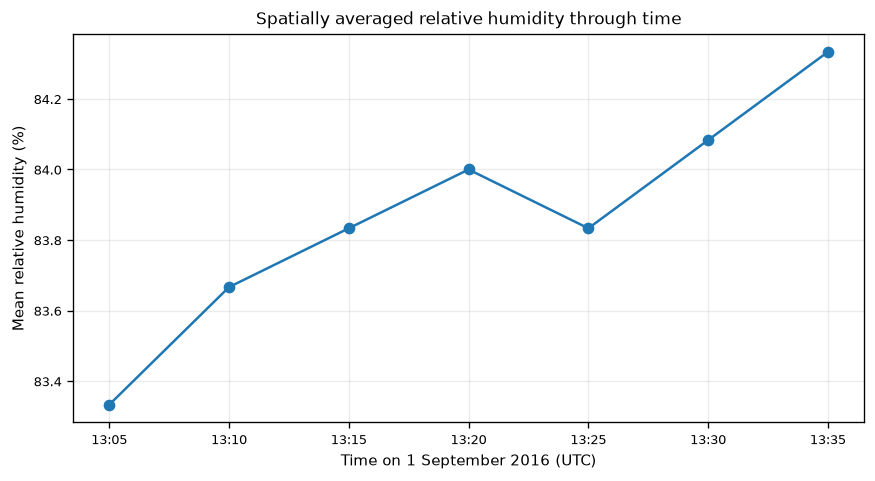

In [16]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

ax.plot(
    time_profile["datetime_utc"],
    time_profile["mean_relative_humidity_percent"],
    marker="o",
)

ax.set_xlabel("Time on 1 September 2016 (UTC)")
ax.set_ylabel("Mean relative humidity (%)")
ax.set_title("Spatially averaged relative humidity through time")
ax.xaxis.set_major_formatter(DateFormatter("%H:%M"))
ax.grid(True, alpha=0.25)

fig.savefig(
    FIGURE_DIR / "weather_humidity_vs_time.png",
    dpi=300,
    bbox_inches="tight",
)
fig.savefig(
    FIGURE_DIR / "weather_humidity_vs_time.pdf",
    bbox_inches="tight",
)
plt.show()

## 16. Concise values for the paper

In [17]:
print(
    f"Mean temperature: "
    f"{acoustic_summary['mean_temperature_f']:.2f} °F "
    f"({acoustic_summary['mean_temperature_c']:.2f} °C)"
)
print(
    f"Mean relative humidity: "
    f"{acoustic_summary['mean_relative_humidity_percent']:.1f}%"
)
print(
    f"Still-air sound speed: "
    f"{acoustic_summary['still_air_sound_speed_mps']:.2f} m/s"
)
print(
    f"0–{MAXIMUM_PATH_HEIGHT_M:.0f} m vector-mean wind: "
    f"{acoustic_summary['path_vector_mean_wind_speed_knots']:.2f} kt "
    f"from "
    f"{acoustic_summary['path_vector_mean_wind_direction_from_deg']:.1f}°"
)
print(
    f"Wind component along SLC-40 → BCHH: "
    f"{acoustic_summary['wind_along_ray_mps']:+.2f} m/s"
)
print(
    f"Wind-corrected effective sound speed: "
    f"{acoustic_summary['effective_sound_speed_mps']:.2f} m/s"
)
print(
    f"Still-air travel time: "
    f"{acoustic_summary['still_air_travel_time_s']:.3f} s"
)
print(
    f"Wind-corrected travel time: "
    f"{acoustic_summary['wind_corrected_travel_time_s']:.3f} s"
)
print(
    f"Wind travel-time correction: "
    f"{acoustic_summary['wind_travel_time_correction_s']:+.3f} s"
)

Mean temperature: 79.44 °F (26.36 °C)
Mean relative humidity: 83.9%
Still-air sound speed: 348.33 m/s
0–65 m vector-mean wind: 8.88 kt from 144.9°
Wind component along SLC-40 → BCHH: +2.65 m/s
Wind-corrected effective sound speed: 350.98 m/s
Still-air travel time: 4.071 s
Wind-corrected travel time: 4.040 s
Wind travel-time correction: -0.031 s
